<a href="https://colab.research.google.com/github/Malli-Yeruva/Python-Assignments/blob/main/foodimg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial image loaded and encoded successfully.
New image loaded and encoded successfully.


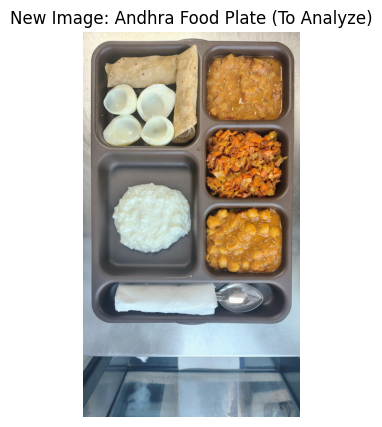


Parsed Final JSON Output:
{
    "food_analysis": [
        {
            "item": "Chapati",
            "count": 2,
            "weight": "60g",
            "volume": "120 ml",
            "nutritional_values": {
                "calories": "150 kcal",
                "protein": "4 g",
                "fats": "2 g",
                "carbohydrates": "30 g"
            }
        },
        {
            "item": "Egg (halved)",
            "count": 4,
            "weight": "200g",
            "volume": "200 ml",
            "nutritional_values": {
                "calories": "280 kcal",
                "protein": "24 g",
                "fats": "20 g",
                "carbohydrates": "2 g"
            }
        },
        {
            "item": "Mixed Veg Poriyal",
            "count": 1,
            "weight": "150g",
            "volume": "150 ml",
            "nutritional_values": {
                "calories": "100 kcal",
                "protein": "3 g",
                "fats": "5 g",

In [3]:
"""
Project: Food Image Analysis using OpenAI API
Description: This script analyzes South Indian Andhra food items in images using the OpenAI API.
It identifies food items, counts eggs and chapatis, estimates volumes and weights, and calculates nutritional values.
The initial image is used as a reference for portion sizes and weights.

"""
import requests
import base64
import json
import cv2
import matplotlib.pyplot as plt
import os

# Step 1: Setting up the environment and API keys
OPENAI_API_KEY = "User your own key" Replace with your actual OpenAI API key
OPENAI_API_URL = "https://api.openai.com/v1/chat/completions"

# Headers for API authentication
openai_headers = {
    "Authorization": f"Bearer {OPENAI_API_KEY}",
    "Content-Type": "application/json"
}

# Step 2: Loading and encoding the initial image with known content
initial_image_path = "/content/drive/MyDrive/AIG_FOOD-IMAGES/WhatsApp Image 2025-05-16 at 10.18.44 PM.jpeg"  # Path to initial image
known_food_items_with_weights = {
    "Mixed Veg Poriyal": "200g",
    "Dosakaya Gravy": "200g",
    "Chana Masala": "150g",
    "Rice": "150g"
}

# Function to encode the image as base64
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
    return encoded_string

# Encode the initial image
try:
    initial_encoded_image = encode_image(initial_image_path)
    print("Initial image loaded and encoded successfully.")
except FileNotFoundError:
    print(f"Error: Initial image file not found at {initial_image_path}. Please check the path and try again.")
    raise
except Exception as e:
    print(f"Error loading initial image: {str(e)}")
    raise



# Step 3: Loading and encoding the new image for analysis
new_image_path = "/content/drive/MyDrive/AIG_FOOD-IMAGES/WhatsApp Image 2025-05-16 at 10.18.43 PM (2).jpeg"
try:
    new_encoded_image = encode_image(new_image_path)
    print("New image loaded and encoded successfully.")
except FileNotFoundError:
    print(f"Error: New image file not found at {new_image_path}. Please check the path and try again.")
    raise
except Exception as e:
    print(f"Error loading new image: {str(e)}")
    raise

# Displaying the new image for verification
new_img = cv2.imread(new_image_path)
new_img = cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.title("New Image: Andhra Food Plate (To Analyze)")
plt.imshow(new_img)
plt.axis('off')
plt.show()

# Step 4: Constructing a prompt for OpenAI API to learn from the initial image and analyze the new image
# Precompute known_items_str to avoid nested f-string expressions
known_items_str = ", ".join([f"{item} ({weight})" for item, weight in known_food_items_with_weights.items()])

# Prompt for OpenAI API
prompt = f"""
You are a food analysis expert with vision capabilities. I will provide two images of plates with South Indian Andhra food items.

First, here is an initial image with known content to help you learn typical portion sizes and weights:
- Food Items: {known_items_str}
This initial image serves as a reference for understanding portion sizes and weights of Andhra food items.

Now, analyze the second image (new image) and perform the following tasks:
1. Identify all food items on the plate.
2. Count the number of full eggs or halved eggs and chapatis (if any) on the plate.
3. Estimate the volume of each food item in common units (e.g., ml, tablespoons, cubic centimeters), using the initial image as a reference for portion sizes.
4. Estimate the weight of each food item (in grams), using the initial image’s weights as a reference.
5. Calculate the nutritional values (calories, protein, fats, carbohydrates) for each food item based on the estimated weights.
6. Carefully identify rice items it can be curd rice ,pongal or normal rice
7. Carefully identify curry items and don't miss any of the items as it can be dosakaya gravy,chana masala or mixed veg poriyal.
Provide your response strictly in the following JSON format:
{{
    "food_analysis": [
        {{
            "item": "[food item]",
            "count": [number],
            "weight": "[weight in grams]g",
            "volume": "[volume estimate]",
            "nutritional_values": {{
                "calories": "[value] kcal",
                "protein": "[value] g",
                "fats": "[value] g",
                "carbohydrates": "[value] g"
            }}
        }},
        ...
    ]
}}
Ensure or recheck before giving the output that all food items are covered, and do not include additional text outside the JSON structure.
"""

# Payload for OpenAI API
payload = {
    "model": "gpt-4o-mini",
    "messages": [
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": prompt
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{initial_encoded_image}"
                    }
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{new_encoded_image}"
                    }
                }
            ]
        }
    ],
    "max_tokens": 1000,
    "temperature": 0.2
}

# Send the request to OpenAI API
try:
    response = requests.post(OPENAI_API_URL, headers=openai_headers, json=payload)
    if response.status_code == 200:
        analysis_response = response.json()['choices'][0]['message']['content']
        # print("OpenAI API Response (Analysis of New Image):")
        # print(analysis_response)
    else:
        print(f"Failed to get response from OpenAI API: {response.status_code}, {response.text}")
        analysis_response = None
except Exception as e:
    print(f"Error querying OpenAI API: {str(e)}")
    analysis_response = None

# Parse the API response (strip Markdown markers before parsing)
final_output = {}
if analysis_response:
    try:
        # Remove Markdown code block markers (```json ... ```)
        cleaned_response = analysis_response.strip()
        if cleaned_response.startswith("```json"):
            cleaned_response = cleaned_response[len("```json"):].strip()
        if cleaned_response.endswith("```"):
            cleaned_response = cleaned_response[:-len("```")].strip()
        final_output = json.loads(cleaned_response)
        print("\nParsed Final JSON Output:")
        print(json.dumps(final_output, indent=4))
    except json.JSONDecodeError:
        print("Error: API response is not in valid JSON format after cleaning.")
        print("Cleaned response:", cleaned_response)
        final_output = {"food_analysis": []}

# Save the JSON output to a file
output_dir = '/content/drive/MyDrive/Food_Seg_Models/Results'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'new_food_analysis_output.json')
with open(output_file, 'w') as f:
    json.dump(final_output, f, indent=4)
print(f"Saved JSON output to {output_file}")